# Notebook Docente 02 — Firmas espectrales (Bloques 3 y 4)
## Teledetección — Maestría en Ingeniería, Universidad del Magdalena
**Sesión 1 · Viernes 17 de julio de 2026**

---

**Este notebook es para que TÚ (el docente) lo proyectes en pantalla.** Los estudiantes
no lo ejecutan hoy — es la versión en Python/Colab del script `gee/02_firmas_espectrales.js`,
por si prefieres mostrar código Python en vez del Code Editor de GEE.

### Qué vas a mostrar
Tomamos tres puntos reales dentro de la zona cacaotera (Ciénaga–Fundación, Magdalena):
uno sobre vegetación densa, uno sobre un cuerpo de agua, y uno sobre suelo desnudo.
Para cada punto, leemos la reflectancia en las 10 bandas ópticas de Sentinel-2 y
graficamos la curva — la firma espectral, la "huella dactilar" del Bloque 4.

**Prerrequisito:** cuenta aprobada en GEE → https://code.earthengine.google.com

### ⚠️ Si `ee.Initialize(project=...)` da "incompatible OAuth2 Client configuration"
Significa que el proyecto de Google Cloud que usaste **no está registrado con Earth
Engine** (por ejemplo, un proyecto viejo de otro curso). Solución:
1. Ve a **https://code.earthengine.google.com/register**
2. Elige **"Unpaid usage"** → categoría académica/investigación
3. Elige **"Create a new Google Cloud Project"** (no reutilices un proyecto de otro curso)
4. Nómbralo, por ejemplo, `teledeteccion-maestria` — Google te da un Project ID
5. Reemplaza ese Project ID en la celda de `ee.Initialize(project='...')` de abajo

Una vez registrado, el mismo Project ID sirve para todos los notebooks del curso —
no hace falta repetir el registro en cada sesión.

In [1]:
# Instalar earthengine-api y geemap (solo la primera vez)
!pip install earthengine-api geemap --quiet
print("✓ Instalación completada")

✓ Instalación completada


In [2]:
# Importar librerías
import ee
import geemap
import matplotlib.pyplot as plt

# Autenticación de Google Earth Engine
ee.Authenticate()

True

In [3]:
ee.Initialize(project='teledeteccion-miguepoloc')  # reemplaza con tu ID de proyecto GEE

print("✓ Google Earth Engine inicializado correctamente")

✓ Google Earth Engine inicializado correctamente


## Paso 1 — Imagen base: Sentinel-2 L2A, temporada seca, zona cacaotera

In [4]:
zona_cacaotera = ee.Geometry.Rectangle([-74.2, 10.5, -73.8, 11.0])

# La Ciénaga Grande real queda al OESTE de la zona cacaotera estrecha —
# ampliamos la búsqueda de agua hacia allá (la vegetación y el suelo sí se
# buscan dentro de zona_cacaotera, más abajo en el Paso 3)
zona_busqueda_agua = ee.Geometry.Rectangle([-74.6, 10.5, -73.8, 11.0])

imagen = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterBounds(zona_busqueda_agua)
    .filterDate('2024-01-01', '2024-03-31')
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
    .median()
)
# OJO: ya NO recortamos (.clip) la imagen aquí. La dejamos con toda la
# cobertura de zona_busqueda_agua para poder muestrear agua real más al oeste.
# El mapa del Paso 2 sí la recorta solo para visualización.

# Orden de bandas = orden del eje X (de onda corta a onda larga)
bandas = ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']
longitudes_onda = [490, 560, 665, 705, 740, 783, 842, 865, 1610, 2190]

print("Imagen lista. Bandas disponibles:", imagen.bandNames().getInfo())

Imagen lista. Bandas disponibles: ['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12', 'AOT', 'WVP', 'SCL', 'TCI_R', 'TCI_G', 'TCI_B', 'MSK_CLDPRB', 'MSK_SNWPRB', 'QA10', 'QA20', 'QA60', 'MSK_CLASSI_OPAQUE', 'MSK_CLASSI_CIRRUS', 'MSK_CLASSI_SNOW_ICE']


## Paso 2 — Ver la zona en falso color (referencia visual)

Abre este mapa para ubicarte: en falso color, la vegetación densa se ve roja
brillante, el agua se ve casi negra, y el suelo desnudo en tonos claros/uniformes.
Ya no necesitas anotar coordenadas a mano — el Paso 3 las encuentra automáticamente
usando los índices espectrales de la propia imagen (más confiable que adivinar a ojo).

In [5]:
m = geemap.Map()
m.centerObject(zona_busqueda_agua, 10)
m.addLayer(imagen.clip(zona_busqueda_agua), {'bands': ['B8', 'B4', 'B3'], 'min': 0, 'max': 4000}, 'Falso color NIR')
m

Map(center=[10.750186827137805, -74.19999999999976], controls=(WidgetControl(options=['position', 'transparent…

## Paso 3 — Encontrar puntos reales de cada cobertura y muestrear reflectancia

**Por qué así y no coordenadas fijas:** unas coordenadas [lon, lat] elegidas a ojo
pueden caer sobre un pixel mixto (ej. borde entre vegetación y agua) y dar una
curva engañosa — de hecho eso fue exactamente lo que pasaba antes en esta celda:
el punto de "agua" y el de "suelo desnudo" resultaban con reflectancia de
vegetación (subían igual que el cacaotal en B8/NIR, lo cual es físicamente
imposible para agua real). Ahora dejamos que la propia imagen encuentre pixeles
que SÍ cumplen la condición espectral de cada cobertura:
- **Vegetación:** NDVI > 0.6 (vegetación densa y sana), buscado en `zona_cacaotera`
- **Agua:** NDWI de McFeeters (B3−B8)/(B3+B8) > 0, buscado en `zona_busqueda_agua`
  (la Ciénaga Grande real queda al oeste de la caja estrecha del cacaotal)
- **Suelo desnudo:** NDVI entre 0.05 y 0.25, buscado en `zona_cacaotera`

Si alguna categoría no encuentra ningún pixel, la función `obtener_punto` lanza un
error explicándolo — en ese caso baja el umbral de la máscara correspondiente o
amplía aún más la región de búsqueda.

In [6]:
# ============================================================
# ENCONTRAR PUNTOS REALES DE CADA COBERTURA (por índice espectral)
# ============================================================
ndvi = imagen.normalizedDifference(['B8', 'B4'])
ndwi = imagen.normalizedDifference(['B3', 'B8'])  # McFeeters 1996, para cuerpos de agua

mascara_vegetacion = ndvi.gt(0.6)
mascara_agua = ndwi.gt(0)
mascara_suelo = ndvi.gt(0.05).And(ndvi.lt(0.25))


def obtener_punto(mascara, region, semilla, num_pixels=3000):
    """Toma un pixel al azar que cumpla la máscara, dentro de la región dada."""
    muestra = mascara.selfMask().sample(
        region=region, scale=10, numPixels=num_pixels, seed=semilla, geometries=True
    )
    n = muestra.size().getInfo()
    if n == 0:
        raise ValueError(
            f"No se encontró ningún pixel que cumpla esta condición espectral dentro "
            f"de la región dada (semilla {semilla}). Baja el umbral de la máscara o "
            f"amplía la región de búsqueda e inténtalo de nuevo."
        )
    return muestra.first().geometry()


# Vegetación y suelo se buscan dentro de la zona cacaotera estrecha;
# el agua se busca en la zona ampliada hacia el oeste (ahí está la Ciénaga Grande)
puntos = {
    'Vegetación (cacaotal)': obtener_punto(mascara_vegetacion, zona_cacaotera, 1),
    'Agua (Ciénaga Grande)': obtener_punto(mascara_agua, zona_busqueda_agua, 2),
    'Suelo desnudo': obtener_punto(mascara_suelo, zona_cacaotera, 3),
}

curvas = {}
for nombre, punto in puntos.items():
    coords = punto.coordinates().getInfo()
    valores = imagen.select(bandas).reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=punto.buffer(15),
        scale=10,
    ).getInfo()
    # Sentinel-2 L2A entrega reflectancia * 10000 -> dividir para tener 0-1
    curvas[nombre] = [(valores.get(b) or 0) / 10000 for b in bandas]
    print(f"{nombre} -> coordenadas encontradas {coords}")
    print(f"  {curvas[nombre]}")

Vegetación (cacaotal) -> coordenadas encontradas [-74.15864234366369, 10.990477968798325]
  [0.02582148394241417, 0.051009219269102984, 0.04086232004429679, 0.10155260243632336, 0.23375545404208198, 0.2792395902547065, 0.2941972314507198, 0.32465517718715386, 0.23376763565891465, 0.12293189368770763]
Agua (Ciénaga Grande) -> coordenadas encontradas [-74.34539963522747, 10.836953706097496]
  [0.03111581125827815, 0.0601205573951435, 0.03517221302428256, 0.05775350441501105, 0.024729442604856516, 0.027432395143487862, 0.021079139072847683, 0.01854271523178808, 0.007553145695364239, 0.005898371964679912]
Suelo desnudo -> coordenadas encontradas [-73.82268243395893, 10.85875888616204]
  [0.0920843612334802, 0.10636018722466963, 0.12256817180616743, 0.13916811674008814, 0.1557253854625551, 0.17368050660792952, 0.1891241189427313, 0.20245115638766525, 0.331631883259912, 0.2612180066079296]


## Paso 4 — Graficar las tres firmas espectrales juntas

Esta es la imagen que proyectas en el Bloque 4 para reemplazar la diapositiva estática
de curvas — es la misma curva, pero calculada en vivo con datos reales de la zona.

La curva se suaviza con interpolación PCHIP (respeta la forma real de los datos,
no inventa picos ni oscila como una spline cúbica normal) — los puntos marcados
siguen siendo los 10 valores reales medidos en cada banda; la línea entre ellos
es solo una ayuda visual para leer la curva en pantalla.

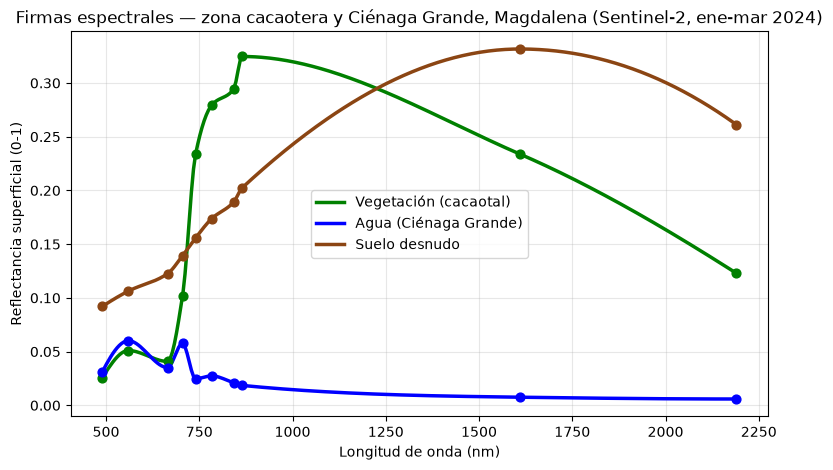

In [7]:
import numpy as np
from scipy.interpolate import PchipInterpolator

colores = {'Vegetación (cacaotal)': 'green', 'Agua (Ciénaga Grande)': 'blue', 'Suelo desnudo': 'saddlebrown'}

x_fino = np.linspace(min(longitudes_onda), max(longitudes_onda), 300)

plt.figure(figsize=(9, 5))
for nombre, valores in curvas.items():
    interpolador = PchipInterpolator(longitudes_onda, valores)
    y_fino = interpolador(x_fino)
    plt.plot(x_fino, y_fino, linewidth=2.5, label=nombre, color=colores[nombre])
    plt.scatter(longitudes_onda, valores, color=colores[nombre], zorder=5, s=40)

plt.title('Firmas espectrales — zona cacaotera y Ciénaga Grande, Magdalena (Sentinel-2, ene-mar 2024)')
plt.xlabel('Longitud de onda (nm)')
plt.ylabel('Reflectancia superficial (0-1)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Guion para la clase

- **¿Por qué la curva del agua cae a casi cero después del rojo?** El agua absorbe casi
  toda la energía en NIR y SWIR — por eso el NDWI distingue agua tan bien.
- **¿Por qué la vegetación tiene un salto entre B4 (rojo) y B8 (NIR)?** La estructura
  celular de la hoja refleja fuertemente en NIR — es la base física del NDVI.
- **¿Por qué el suelo sube de forma gradual sin saltos?** No tiene la estructura celular
  de la hoja ni la absorción del agua — su curva es la más "plana" de las tres.

**Nota técnica:** el punto de agua se busca en `zona_busqueda_agua` (una caja más ancha
hacia el oeste), no en `zona_cacaotera` — la Ciénaga Grande real queda fuera de la caja
estrecha del cacaotal, así que buscar agua ahí no encontraba ningún pixel válido.
Vegetación y suelo sí se buscan dentro de `zona_cacaotera`, que es donde tiene sentido
pedagógico mostrarlos (la finca cacaotera del Artículo 1).

### Alternativa 100% interactiva en vivo
Si prefieres hacer clic en el mapa en tiempo real (en vez de coordenadas fijas), usa
el script `gee/02_firmas_espectrales.js` en el Code Editor de GEE — allí cada clic
agrega una curva nueva al gráfico al instante.